In [134]:
import os
import io
import base64
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image, ImageFilter, ImageEnhance
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score
from inference_sdk import InferenceHTTPClient
import matplotlib.pyplot as plt
from torchvision import transforms, models


# ========= Rboboflow Setup ========
API_KEY = "WK8EcYwUZ01s6GBR6QB1" # from roboflow

# change folder path to fish_dataset location here:
INPUT_FOLDER = r"C:\Users\shanw\OneDrive\Desktop\ME232\Project\fish_dataset"

WORKSPACE = "shanwens-workspace" # from roboflow
WORKFLOW_ID = "fish-detection-cropped-1777939871146" # from roboflow
data_folder = INPUT_FOLDER

client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=API_KEY
)

# ========== Detect classes from from fish_dataset ===========
class_names = sorted([
    d for d in os.listdir(data_folder)
    if os.path.isdir(os.path.join(data_folder, d))
])

# Count and Display classes
num_classes=len(class_names)
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
print(len(class_names), class_names)

12 ['BlueFinMarlin', 'CommonCarp', 'blackbanded', 'blackcrappie', 'bluegill', 'greenSunFish', 'mud', 'pumpkinseed', 'redbreast', 'rockbass', 'warmouth', 'whitecrappie']


In [135]:
# ================ Run Roboflow =============

# This section runs dataset through the secmentation model via Roboflow
# and stores cropped images temporarily (does not save them)
# *will take a while*

cropped_images = []
cropped_labels = []

for class_name in class_names:
    input_folder = os.path.join(data_folder, class_name)
    label = class_to_idx[class_name]

    print(f"\nProcessing class: {class_name}")

    for filename in sorted(os.listdir(input_folder)):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        filepath = os.path.join(input_folder, filename)
        print(f"  Processing: {filename}")

        result = client.run_workflow(
            workspace_name=WORKSPACE,
            workflow_id=WORKFLOW_ID,
            images={"image": filepath},
            use_cache=True
        )

        crop_list = result[0]["crops"]

        if len(crop_list) == 0:
            print("    -> No fish detected")
            continue

        for b64_string in crop_list:
            img_bytes = base64.b64decode(b64_string)
            img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

            cropped_images.append(img)
            cropped_labels.append(label)

print("\nDone.")
print("Total cropped fish images:", len(cropped_images))



Processing class: BlueFinMarlin
  Processing: download (1).jpg
    -> No fish detected
  Processing: download (2).jpg
  Processing: download (3).jpg
  Processing: download (4).jpg
    -> No fish detected
  Processing: download (5).jpg
    -> No fish detected
  Processing: download.jpg
  Processing: images (1).jpg
  Processing: images (2).jpg
    -> No fish detected
  Processing: images (3).jpg
    -> No fish detected
  Processing: images (4).jpg
  Processing: images (5).jpg
  Processing: images (6).jpg
  Processing: images (7).jpg
  Processing: images (8).jpg
  Processing: images.jpg
  Processing: large (1).jpeg
  Processing: large (1).jpg
  Processing: large (1).png
  Processing: large (10).jpeg
  Processing: large (10).jpg
  Processing: large (11).jpeg
  Processing: large (11).jpg
  Processing: large (12).jpeg
  Processing: large (12).jpg
  Processing: large (13).jpeg
  Processing: large (13).jpg
  Processing: large (14).jpeg
  Processing: large (14).jpg
  Processing: large (15).jpe

In [9]:
# ================== Displays a random sample of the cropped images =============

plt.figure(figsize=(10, 6))

sample_indices = random.sample(
    range(len(cropped_images)),
    min(6, len(cropped_images))
)

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 3, i + 1)

    plt.imshow(cropped_images[idx])
    plt.title(class_names[cropped_labels[idx]])

    plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'random' is not defined

<Figure size 1000x600 with 0 Axes>

In [146]:
# ============= Letterboxing ================

# Code is kept here, but currently not utilizing due to worse performance (see report)

from PIL import ImageOps

def resize_with_padding(img, target_size=(299, 299), fill=(0,0,0)):

    target_w, target_h = target_size

    # Resize while preserving aspect ratio
    img.thumbnail((target_w, target_h), Image.Resampling.LANCZOS)

    # Compute padding
    delta_w = target_w - img.size[0]
    delta_h = target_h - img.size[1]

    padding = (
        delta_w // 2,
        delta_h // 2,
        delta_w - (delta_w // 2),
        delta_h - (delta_h // 2)
    )

    # Add padding
    img = ImageOps.expand(img, padding, fill=fill)

    return img

In [7]:
# ========= Data Augmentation =============

# Applies each augmentation randomly by a random amount within a range.
# Can tune probability/augmentation ranges

class RandomFishAugment:
    def __init__(self, input_size=(299, 299)):
        self.input_size = input_size

    def __call__(self, img):
        # img = resize_with_padding(img, self.input_size) #uncomment for letterboxing
        img = img.resize(self.input_size)

        #rotate
        if random.random() < 0.4:
            k = random.randint(0, 3)
            img = img.rotate(90 * k)
            
        #flip
        if random.random() < 0.4:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            
        #blur
        if random.random() < 0.4:
            sigma = 3 * random.random()
            img = img.filter(ImageFilter.GaussianBlur(radius=sigma))
            
        #brightness level
        if random.random() < 0.4:
            factor = 0.525 + (1.7 - 0.525) * random.random()
            img = ImageEnhance.Brightness(img).enhance(factor)

        return img

In [8]:
# ========= Transform Images ============

input_size = (299, 299)

train_transform = transforms.Compose([
    RandomFishAugment(input_size),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.ToTensor(),
])

NameError: name 'transforms' is not defined

In [166]:
# ======== Organize Data & Augment Every Epoch ===========
class FishCropDataset(torch.utils.data.Dataset):

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

In [167]:
# ======== Split Data =========

# Currently set at 0.7 train, 0.15 test, 0.15 validation

indices = np.arange(len(cropped_images))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=cropped_labels,
    random_state=42
)

temp_labels = [cropped_labels[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

train_dataset_full = FishCropDataset(cropped_images, cropped_labels, transform=train_transform)
val_dataset_full   = FishCropDataset(cropped_images, cropped_labels, transform=val_test_transform)
test_dataset_full  = FishCropDataset(cropped_images, cropped_labels, transform=val_test_transform)

train_dataset = Subset(train_dataset_full, train_idx)
val_dataset   = Subset(val_dataset_full, val_idx)
test_dataset  = Subset(test_dataset_full, test_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

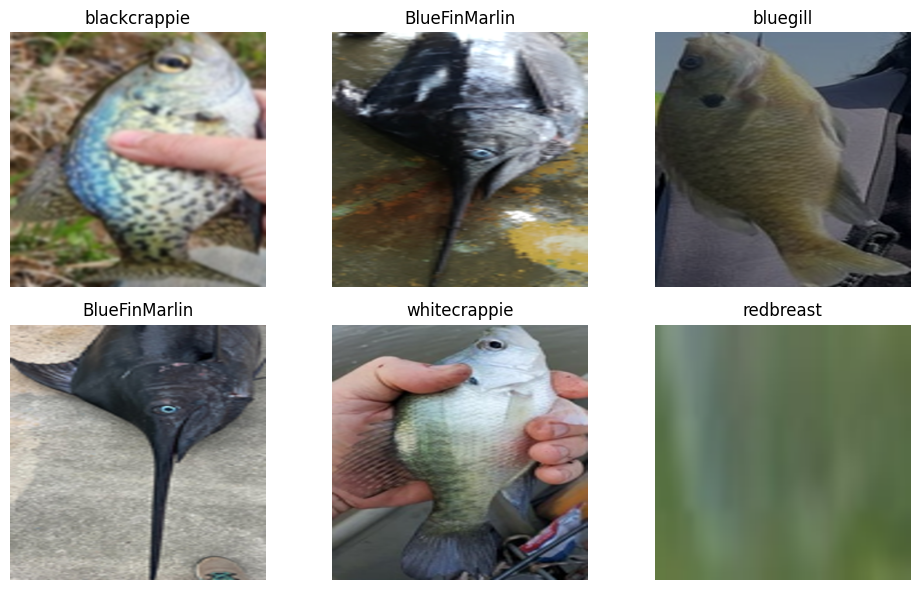

In [168]:
# ======== Preview Samples of Augmented Images ===============

images, labels_batch = next(iter(train_loader))

plt.figure(figsize=(10, 6))
for i in range(6):
    img = images[i].permute(1, 2, 0).numpy()
    label = class_names[labels_batch[i]]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [169]:
# ============ Load ResNet18 ==========

# Load ResNet18 for transferlearning by repalcing final layer for fish classification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.4),  # added weighted decay for overfitting
    nn.Linear(num_features, num_classes)
)

model = model.to(device)

Using device: cpu


In [170]:
# ============= Training setup =========

# Tune hyperparameters here

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=5e-4  # added weighted decay for overfitting
)

num_epochs = 20

train_losses = []
train_accuracies = []
val_accuracies = []

In [171]:
# ======= Train ===========

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels_batch).item()
        total_train += labels_batch.size(0)

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # Validation
    model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct_val += torch.sum(preds == labels_batch).item()
            total_val += labels_batch.size(0)

    val_acc = correct_val / total_val

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.4f} "
          f"Val Acc: {val_acc:.4f}")

Epoch [1/20] Loss: 1.5474 Train Acc: 0.4822 Val Acc: 0.7068
Epoch [2/20] Loss: 0.8273 Train Acc: 0.7377 Val Acc: 0.8114
Epoch [3/20] Loss: 0.6235 Train Acc: 0.8123 Val Acc: 0.8182
Epoch [4/20] Loss: 0.5190 Train Acc: 0.8376 Val Acc: 0.8432
Epoch [5/20] Loss: 0.4305 Train Acc: 0.8674 Val Acc: 0.8614
Epoch [6/20] Loss: 0.3454 Train Acc: 0.9020 Val Acc: 0.8523
Epoch [7/20] Loss: 0.3190 Train Acc: 0.9044 Val Acc: 0.8545
Epoch [8/20] Loss: 0.2863 Train Acc: 0.9132 Val Acc: 0.8886
Epoch [9/20] Loss: 0.2618 Train Acc: 0.9308 Val Acc: 0.8727
Epoch [10/20] Loss: 0.2395 Train Acc: 0.9288 Val Acc: 0.8545
Epoch [11/20] Loss: 0.2254 Train Acc: 0.9332 Val Acc: 0.9045
Epoch [12/20] Loss: 0.2022 Train Acc: 0.9405 Val Acc: 0.8773
Epoch [13/20] Loss: 0.2182 Train Acc: 0.9366 Val Acc: 0.8705
Epoch [14/20] Loss: 0.1950 Train Acc: 0.9444 Val Acc: 0.9091
Epoch [15/20] Loss: 0.1679 Train Acc: 0.9517 Val Acc: 0.8909
Epoch [16/20] Loss: 0.1590 Train Acc: 0.9508 Val Acc: 0.9000
Epoch [17/20] Loss: 0.1796 Train 

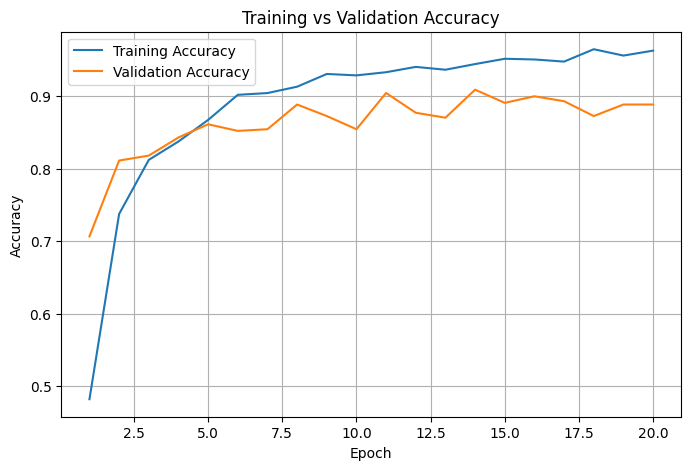

In [172]:
# =========== Plot Training vs Validation Accuracy ===========
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

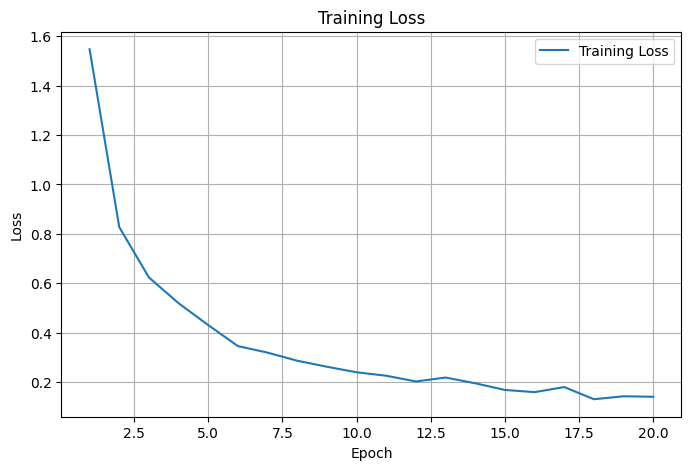

In [173]:
# ============ Plot Training Loss =================
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [174]:
# ============== Evaluate on test set ===============

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 86.36%


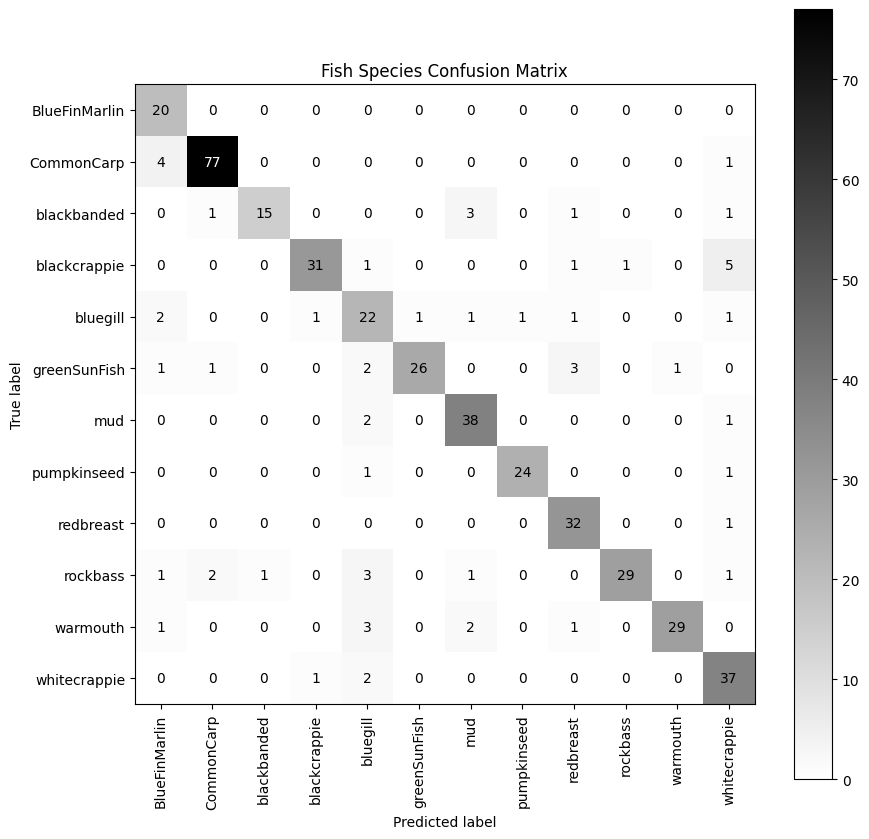

In [175]:
# ======== Confusion matrix ==============

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(
    ax=ax,
    cmap="binary",
    xticks_rotation=90,
    values_format="d"
)
plt.title("Fish Species Confusion Matrix")
plt.show()

In [176]:
# ================== Calculate Recall ====================
all_labels = []
all_preds = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

recall = recall_score(all_labels, all_preds, average='macro')
print("Recall:", recall)

Recall: 0.8549614772038883


In [ ]:

# ========= Fish Species Classifier ===============

# This is the actual fish species classifier using the trained model.
# Input any fish image by updating the file path below

# Path to image
image_path = r"C:\Users\shanw\OneDrive\Desktop\ME232\Project\fish_dataset\blackbanded\bb1.jpg"
# Load image
image = Image.open(image_path).convert("RGB")

# Apply SAME transform used for validation/testing
input_tensor = val_test_transform(image).unsqueeze(0).to(device)

# Set model to evaluation mode
model.eval()

# Disable gradients
with torch.no_grad():
    outputs = model(input_tensor)

    # Convert outputs to probabilities
    probabilities = torch.softmax(outputs, dim=1)

    # Get highest probability prediction
    confidence, predicted = torch.max(probabilities, 1)

# Convert predicted index to class name
predicted_class = class_names[predicted.item()]

# Display image
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence.item()*100:.2f}%")
plt.axis("off")
plt.show()

print("Predicted Fish Species:", predicted_class)
print(f"Confidence: {confidence.item()*100:.2f}%")